# Model Comparison: Which Classifier Works Best?

## Problem
We have now seen several classifiers on the same student pass/fail data. Which one should we pick?

## Objective
Compare **six models** fairly on the same data using **5-fold cross-validation** (more reliable than a single train/test split), and decide whether any model is clearly better.

Models compared: Logistic Regression, KNN, Decision Tree, Random Forest, Support Vector Machine (SVM) and Naive Bayes.

**Dataset:** `data/student_pass_fail.csv` (300 rows). The data is **synthetic** (randomly generated with a fixed seed by `data/generate_data.py`) for learning purposes. It does not describe real students.

| Column | Meaning |
|--------|---------|
| `study_hours` | Daily study hours (0 to 10) |
| `attendance_pct` | Attendance percentage (50 to 100) |
| `previous_score` | Score in the previous exam (20 to 100) |
| `passed` | 1 = passed, 0 = failed (target) |

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score

## 2. Load the Dataset and Split

In [2]:
from pathlib import Path

def find_data(filename):
    """Find data/<filename> by searching this notebook's folder and its parent folders."""
    here = Path.cwd().resolve()
    for folder in [here, *here.parents]:
        candidate = folder / "data" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find data/{filename}. Open this notebook from inside the project folder."
    )


In [3]:
df = pd.read_csv(find_data("student_pass_fail.csv"))
features = ["study_hours", "attendance_pct", "previous_score"]
X = df[features]
y = df["passed"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Shape:", df.shape, "| Training rows:", len(X_train), "| Test rows:", len(X_test))

Shape: (300, 4) | Training rows: 240 | Test rows: 60


## 3. Define the Models

- **Logistic Regression, KNN and SVM** depend on distances or scales, so they are wrapped in a pipeline with `StandardScaler`.
- **Decision Tree, Random Forest and Naive Bayes** do not need scaling.
- The settings of KNN (K = 15) and the Decision Tree (depth 5) are the ones chosen by cross-validation in the earlier notebooks.

### What is SVM and Naive Bayes?
- **SVM** finds the boundary that separates the two classes with the widest possible margin. With the default RBF kernel, the boundary can be curved.
- **Naive Bayes** uses probability: it estimates how typical each feature value is for passing and for failing students, and combines them while (naively) assuming the features are independent.

In [4]:
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "KNN (K=15)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)),
    "Decision Tree (depth 5)": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM (RBF)": make_pipeline(StandardScaler(), SVC()),
    "Naive Bayes": GaussianNB(),
}
print(len(models), "models ready")

6 models ready


## 4. Compare with Cross-Validation

**5-fold cross-validation** splits all 300 students into 5 parts. Each model is trained 5 times, each time testing on a different part, so every student is used for testing once. We report the **mean accuracy** and the **standard deviation** (how much the score changes between folds).

We also report the score on our usual 60-student test split and the F1 score (a balance of precision and recall).

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=cv)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rows.append({
        "Model": name,
        "CV accuracy": cv_scores.mean(),
        "CV std": cv_scores.std(),
        "Test accuracy": model.score(X_test, y_test),
        "Test F1": f1_score(y_test, pred),
    })

results = pd.DataFrame(rows).sort_values("CV accuracy", ascending=False).reset_index(drop=True).round(3)
results

,Model,CV accuracy,CV std,Test accuracy,Test F1
0,Random Forest,0.847,0.024,0.867,0.833
1,Logistic Regression,0.840,0.031,0.883,0.851
2,Naive Bayes,0.837,0.037,0.883,0.851
3,KNN (K=15),0.833,0.035,0.867,0.840
4,SVM (RBF),0.833,0.028,0.900,0.875
5,Decision Tree (depth 5),0.830,0.036,0.783,0.745


## 5. Visualize

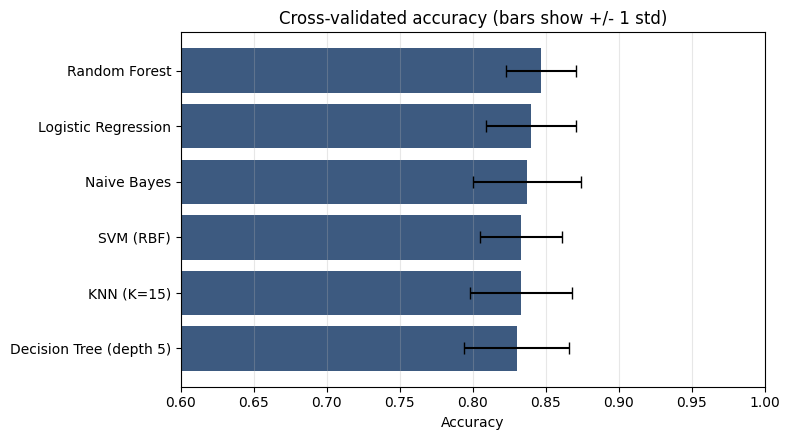

In [6]:
plot_data = results.sort_values("CV accuracy")

plt.figure(figsize=(8, 4.5))
plt.barh(plot_data["Model"], plot_data["CV accuracy"], xerr=plot_data["CV std"],
         color="#3D5A80", capsize=4)
plt.xlim(0.6, 1.0)
plt.title("Cross-validated accuracy (bars show +/- 1 std)")
plt.xlabel("Accuracy")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion

- All six models score between about **83% and 85%** in cross-validation. The differences between them (1 to 2 points) are **smaller than the standard deviation** (2 to 4 points), so no model is clearly better than the others.
- **Random Forest** has the highest cross-validated accuracy (about 84.7%) and the most stable results, but only by a tiny margin.
- **Logistic Regression** is almost as accurate (about 84.0%), and it is the simplest and easiest to explain. When models tie, the simpler one is the better choice.
- On the single 60-student test split the ranking looks different (SVM scores 90%, the Decision Tree only 78%). This shows how misleading **one small test split** can be, and why cross-validation is more trustworthy.
- **Important caveat:** this data was generated from a logistic formula, so logistic regression is naturally a good match. On messy real-world data, the ranking could be different. Always compare several models on your own data.